# 09_GAN_training
Training completo del generatore GAN (allenamento lungo, non un breve trial come nel tuning), su Colab con GPU L4. Usa i learning rate scelti in `08_GAN_hyperparameter_tuning.ipynb`.

## Cosa produce
Solo i **pesi del generatore** allenato -- serviranno come prior generativo per il DPS (prossimo notebook, non ancora fatto). Il discriminatore serve solo qui, durante il training, poi si scarta.

## Checkpoint e ripresa
Salva un checkpoint completo su Drive ogni `CHECKPOINT_EVERY` epoche (generatore, discriminatore, entrambi gli ottimizzatori, numero di epoca) -- se il notebook si disconnette, rilancialo: riparte automaticamente dall'ultimo checkpoint invece che da zero.

## Prerequisito
`dataset_resized.zip` su Drive (serve solo `train_resized` qui; `validation_resized` e' usata per monitorare la FID durante il training, non per allenare).

In [ ]:
# DA ESEGUIRE SU COLAB PER ADDESTRARE LA RETE E OTTENERE I PESI (QUESTO GENERA I PESI MIGLIORI)

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DATASET_RESIZED_ZIP = "/content/drive/MyDrive/dataset_resized.zip"
LOCAL_DATASET_DIR = Path("/content/dataset_resized")

if not LOCAL_DATASET_DIR.exists():
    print("Estraggo dataset_resized...")
    get_ipython().system('unzip -q "{DATASET_RESIZED_ZIP}" -d /content/')
else:
    print("dataset_resized gia' estratto, salto.")

TRAIN_DIR = LOCAL_DATASET_DIR / "train_resized"
VALIDATION_DIR = LOCAL_DATASET_DIR / "validation_resized"

assert TRAIN_DIR.exists(), f"Non trovo {TRAIN_DIR}"
assert VALIDATION_DIR.exists(), f"Non trovo {VALIDATION_DIR}"

print(f"Immagini di train: {len(list(TRAIN_DIR.rglob('*.png')))}")

Mounted at /content/drive
Estraggo dataset_resized...
Immagini di train: 2733


In [2]:
get_ipython().system('pip install -q torchmetrics[image]')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.6 MB/s eta 0:00:00


In [3]:
import time
import json

import numpy as np
from skimage import io
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torchmetrics.image.fid import FrechetInceptionDistance

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo in uso: cuda
GPU: NVIDIA A100-SXM4-40GB


In [4]:
# ============================================================
# Dataset (stesso caricamento usato nel tuning)
# ============================================================

def load_normalized_image(path: Path) -> np.ndarray:
    image = io.imread(path).astype(np.float32)
    max_value = np.iinfo(io.imread(path).dtype).max
    return image / max_value


class CTImageDataset(Dataset):
    def __init__(self, root_dir: Path):
        self.paths = sorted(root_dir.rglob("*.png"))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = load_normalized_image(self.paths[idx])
        return torch.from_numpy(image).float().unsqueeze(0)

In [6]:
# ============================================================
# Architettura (identica a 08_GAN_hyperparameter_tuning.ipynb)
# ============================================================

class Generator(nn.Module):
    def __init__(self, latent_dim=100, ngf=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 8), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),

            nn.ConvTranspose2d(ngf, ngf // 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf // 2), nn.ReLU(True),

            nn.ConvTranspose2d(ngf // 2, 1, 4, 2, 1, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z.view(z.size(0), self.latent_dim, 1, 1))


class Discriminator(nn.Module):
    def __init__(self, ndf=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, ndf // 2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf // 2, ndf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, ndf * 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 16), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 16, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1)


def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [7]:
# ============================================================
# Configurazione -- learning rate presi dal tuning (fallback ai
# valori di default DCGAN se il file di tuning non e' disponibile)
# ============================================================

IMG_SIZE = 256
LATENT_DIM = 100
NGF = 32
NDF = 32

BATCH_SIZE = 32
FULL_EPOCHS = 150
CHECKPOINT_EVERY = 10
LABEL_SMOOTHING = 0.9
FID_N_SAMPLES = 300

TUNING_RESULT_PATH = Path("/content/drive/MyDrive/gan_tuning/best_gan_lr.json")

if TUNING_RESULT_PATH.exists():
    with open(TUNING_RESULT_PATH) as f:
        best = json.load(f)
    LR_G, LR_D = best["lr_g"], best["lr_d"]
    print(f"Learning rate presi dal tuning: lr_G={LR_G}, lr_D={LR_D} (FID={best['fid']:.2f})")
else:
    LR_G, LR_D = 2e-4, 2e-4
    print(f"File di tuning non trovato, uso i default DCGAN: lr_G={LR_G}, lr_D={LR_D}")

train_dataset = CTImageDataset(TRAIN_DIR)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=2)
print(f"Immagini di train: {len(train_dataset)} -- {len(train_loader)} batch per epoca")

Learning rate presi dal tuning: lr_G=0.0002, lr_D=0.0002 (FID=385.09)
Immagini di train: 2733 -- 85 batch per epoca


In [8]:
# ============================================================
# Riferimento FID (immagini vere di validation) per monitorare il
# training senza mai toccare il test set
# ============================================================

def to_fid_input(x: torch.Tensor) -> torch.Tensor:
    return x.repeat(1, 3, 1, 1)


val_dataset = CTImageDataset(VALIDATION_DIR)
val_indices = np.random.RandomState(123).choice(len(val_dataset), size=min(FID_N_SAMPLES, len(val_dataset)), replace=False)
real_images = torch.stack([val_dataset[i] for i in val_indices])


def compute_fid(generator, n_samples=FID_N_SAMPLES, batch_size=32):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(DEVICE)
    for i in range(0, real_images.size(0), batch_size):
        batch = real_images[i:i + batch_size].to(DEVICE)
        fid.update(to_fid_input(batch), real=True)

    generator.eval()
    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            n = min(batch_size, n_samples - i)
            z = torch.randn(n, LATENT_DIM, device=DEVICE)
            fake = generator(z)
            fid.update(to_fid_input(fake), real=False)
    generator.train()

    return float(fid.compute())

In [9]:
# ============================================================
# Setup del modello + RIPRESA da checkpoint se presente su Drive
# ============================================================

CHECKPOINT_DIR = Path("/content/drive/MyDrive/gan_checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / "latest_checkpoint.pth"
SAMPLES_DIR = CHECKPOINT_DIR / "sample_grids"
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

generator = Generator(LATENT_DIM, NGF).to(DEVICE)
discriminator = Discriminator(NDF).to(DEVICE)

opt_g = torch.optim.Adam(generator.parameters(), lr=LR_G, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

start_epoch = 0
history = {"g_loss": [], "d_loss": [], "fid": {}}
best_fid = float("inf")
BEST_WEIGHTS_PATH = CHECKPOINT_DIR / "generator_weights_best.pth"

if CHECKPOINT_PATH.exists():
    print(f"Checkpoint trovato, riprendo da: {CHECKPOINT_PATH}")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    generator.load_state_dict(ckpt["generator"])
    discriminator.load_state_dict(ckpt["discriminator"])
    opt_g.load_state_dict(ckpt["opt_g"])
    opt_d.load_state_dict(ckpt["opt_d"])
    start_epoch = ckpt["epoch"] + 1
    history = ckpt["history"]
    best_fid = ckpt.get("best_fid", float("inf"))   # .get per compatibilita' con checkpoint salvati prima di questa modifica
    print(f"Riparto dall'epoca {start_epoch}/{FULL_EPOCHS} -- miglior FID finora: {best_fid:.2f}" if best_fid != float("inf") else f"Riparto dall'epoca {start_epoch}/{FULL_EPOCHS}")
else:
    print("Nessun checkpoint trovato, parto da zero.")
    generator.apply(weights_init)
    discriminator.apply(weights_init)

Nessun checkpoint trovato, parto da zero.


In [10]:
# ============================================================
# TRAINING -- salva checkpoint + griglia di campioni ogni
# CHECKPOINT_EVERY epoche, cosi' se il notebook si disconnette basta
# rilanciare questa cella per riprendere da dove si era arrivati.
# ============================================================

for epoch in range(start_epoch, FULL_EPOCHS):
    epoch_g_loss, epoch_d_loss = 0.0, 0.0

    for real in tqdm(train_loader, desc=f"Epoca {epoch + 1}/{FULL_EPOCHS}", leave=False):
        real = real.to(DEVICE)
        b = real.size(0)

        # --- Discriminatore ---
        opt_d.zero_grad()
        real_labels = torch.full((b,), LABEL_SMOOTHING, device=DEVICE)
        fake_labels = torch.zeros(b, device=DEVICE)

        loss_d_real = criterion(discriminator(real), real_labels)
        z = torch.randn(b, LATENT_DIM, device=DEVICE)
        fake = generator(z)
        loss_d_fake = criterion(discriminator(fake.detach()), fake_labels)
        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        opt_d.step()

        # --- Generatore ---
        opt_g.zero_grad()
        loss_g = criterion(discriminator(fake), real_labels)
        loss_g.backward()
        opt_g.step()

        epoch_g_loss += loss_g.item()
        epoch_d_loss += loss_d.item()

    avg_g = epoch_g_loss / len(train_loader)
    avg_d = epoch_d_loss / len(train_loader)
    history["g_loss"].append(avg_g)
    history["d_loss"].append(avg_d)
    print(f"Epoca {epoch + 1}/{FULL_EPOCHS} -- loss_G: {avg_g:.4f}  loss_D: {avg_d:.4f}")

    is_checkpoint_epoch = (epoch + 1) % CHECKPOINT_EVERY == 0
    is_last_epoch = (epoch + 1) == FULL_EPOCHS

    if is_checkpoint_epoch or is_last_epoch:
        fid_score = compute_fid(generator)
        history["fid"][str(epoch + 1)] = fid_score
        print(f"  FID a epoca {epoch + 1}: {fid_score:.2f}")

        generator.eval()
        with torch.no_grad():
            z = torch.randn(9, LATENT_DIM, device=DEVICE)
            samples = generator(z).cpu().numpy()
        generator.train()

        fig, axs = plt.subplots(3, 3, figsize=(9, 9))
        for ax, img in zip(axs.flat, samples):
            ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
        plt.suptitle(f"Epoca {epoch + 1} -- FID={fid_score:.2f}")
        plt.tight_layout()
        plt.savefig(SAMPLES_DIR / f"epoch_{epoch + 1:04d}.png", dpi=120)
        plt.close(fig)

        # Salva i pesi del generatore SOLO se questa e' la FID migliore vista finora
        # -- a differenza del checkpoint "ultima epoca", questo file non viene mai
        # sovrascritto da un risultato peggiore (il training GAN puo' degenerare
        # dopo aver raggiunto un buon punto, quindi "ultimo" non e' sempre "migliore").
        if fid_score < best_fid:
            best_fid = fid_score
            torch.save(generator.state_dict(), BEST_WEIGHTS_PATH)
            print(f"  Nuovo miglior FID ({best_fid:.2f}) -- pesi salvati in generator_weights_best.pth")

        torch.save({
            "epoch": epoch,
            "generator": generator.state_dict(),
            "discriminator": discriminator.state_dict(),
            "opt_g": opt_g.state_dict(),
            "opt_d": opt_d.state_dict(),
            "history": history,
            "best_fid": best_fid,
        }, CHECKPOINT_PATH)
        print(f"  Checkpoint salvato (epoca {epoch + 1}).")

print("\nTraining completato.")

Epoca 1/150:   0%|          | 0/85 [00:00<?, ?it/s]

Epoca 1/150 -- loss_G: 9.1719  loss_D: 0.5180


Epoca 2/150:   0%|          | 0/85 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x795ef4eb65c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x795ef4eb65c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoca 2/150 -- loss_G: 10.2048  loss_D: 0.5374


...

Epoca 148/150 -- loss_G: 5.5018  loss_D: 0.3560


Epoca 149/150:   0%|          | 0/85 [00:00<?, ?it/s]

Epoca 149/150 -- loss_G: 5.6471  loss_D: 0.3548


Epoca 150/150:   0%|          | 0/85 [00:00<?, ?it/s]

Epoca 150/150 -- loss_G: 5.4720  loss_D: 0.3730
  FID a epoca 150: 328.32
  Checkpoint salvato (epoca 150).

Training completato.


In [11]:
# ============================================================
# Salvataggio finale: solo i pesi del generatore (quello che servira'
# per il DPS), separato dal checkpoint completo di training.
# ============================================================

# generator_weights_best.pth e' gia' stato salvato durante il training (ogni
# volta che la FID migliorava) -- qui solo un riepilogo, nessun file nuovo da
# salvare (non teniamo un file separato per "l'ultima epoca": non serve al
# resto della pipeline, e i pesi dell'ultima epoca sono comunque gia' dentro
# latest_checkpoint.pth se mai volessi controllarli).
print(f"Pesi con la FID migliore ({best_fid:.2f}) salvati in: {BEST_WEIGHTS_PATH}")
print("Per il DPS, carica questo file -- e' l'unico pezzo che ti serve da qui in poi.")

Pesi con la FID migliore (314.77) salvati in: /content/drive/MyDrive/gan_checkpoints/generator_weights_best.pth
Per il DPS, carica questo file -- e' l'unico pezzo che ti serve da qui in poi.


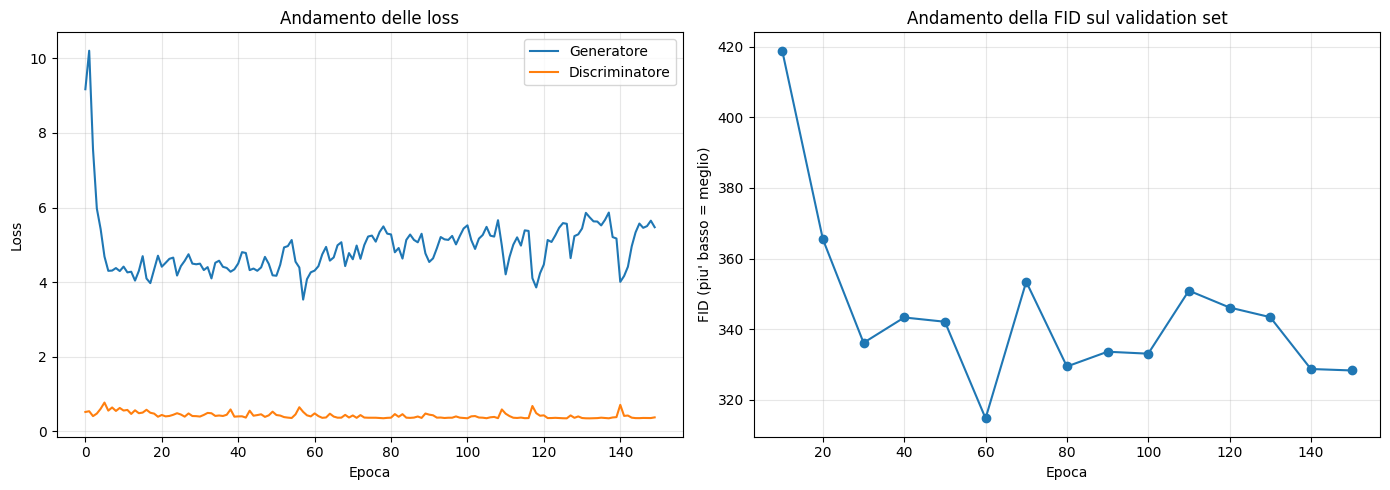

In [12]:
# ============================================================
# Andamento di loss e FID durante tutto il training
# ============================================================

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(history["g_loss"], label="Generatore")
axs[0].plot(history["d_loss"], label="Discriminatore")
axs[0].set_xlabel("Epoca")
axs[0].set_ylabel("Loss")
axs[0].set_title("Andamento delle loss")
axs[0].legend()
axs[0].grid(alpha=0.3)

fid_epochs = sorted(int(e) for e in history["fid"].keys())
fid_values = [history["fid"][str(e)] for e in fid_epochs]
axs[1].plot(fid_epochs, fid_values, marker="o")
axs[1].set_xlabel("Epoca")
axs[1].set_ylabel("FID (piu' basso = meglio)")
axs[1].set_title("Andamento della FID sul validation set")
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "training_curves.png", dpi=150)
plt.show()

## Prossimo passo
I pesi in `gan_checkpoints/generator_weights_best.pth` (quelli con la FID migliore osservata durante il training, non necessariamente l'ultima epoca) sono pronti per essere caricati nel notebook DPS (da fare dopo), che li usera' come prior generativo dentro il ciclo di campionamento guidato dai sinogrammi di test.